In [1]:
# Cell 1: Setup, Configuration & Imports
import os
import shutil
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Input, Add, Multiply, Activation, Reshape
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# CONFIGURATION

DRIVE_DATASET_PATH = "/content/drive/MyDrive/Brain_Tumor_Mendeley"
LOCAL_PATH = "/content/temp_mendeley_data"

CLASSES = ["glioma", "meningioma", "pituitary", "notumor"]

# Image Sizes
IMG_SIZE_CNN = 128   # Higher resolution for texture detail
IMG_SIZE_MOB = 224   # Required for MobileNetV2

BATCH_SIZE = 16
EPOCHS = 40

print(f"TensorFlow Version: {tf.__version__}")

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Cell 2: Data Loading & Split

# 1. Copy Data for Speed
if not os.path.exists(LOCAL_PATH):
    print(f"Copying data to Local VM...")
    try:
        shutil.copytree(DRIVE_DATASET_PATH, LOCAL_PATH)
        print("Copy complete.")
    except Exception as e:
        print(f"Error copying: {e}")
        print(f"Please ensure '{DRIVE_DATASET_PATH}' exists in your Google Drive.")
else:
    print("Data exists locally.")

# 2. Helper to get paths
def get_file_paths(root_dir, classes):
    filepaths = []
    labels = []
    if not os.path.exists(root_dir): return [], []

    for label_id, label_name in enumerate(classes):
        class_dir = os.path.join(root_dir, label_name)
        if not os.path.exists(class_dir):
            class_dir = os.path.join(root_dir, label_name.capitalize())

        if os.path.exists(class_dir):
            files = [os.path.join(class_dir, f) for f in os.listdir(class_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            filepaths.extend(files)
            labels.extend([label_id] * len(files))
    return filepaths, labels

# 3. Gather Paths
train_dir = os.path.join(LOCAL_PATH, "Train")
test_dir = os.path.join(LOCAL_PATH, "Test")

train_paths, train_labels = get_file_paths(train_dir, CLASSES)
test_paths, test_labels_raw = get_file_paths(test_dir, CLASSES)

# DEBUG CHECK
if len(train_paths) == 0:
    raise ValueError(f"No training images found in {train_dir}. Check your Drive path!")
if len(test_paths) == 0:
    raise ValueError(f"No testing images found in {test_dir}. Check your Drive path!")

# 4. Create Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    train_paths, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

print(f"\nData Splits:")
print(f"Training:   {len(X_train)} images")
print(f"Validation: {len(X_val)} images")
print(f"Testing:    {len(test_paths)} images")

Copying data to Local VM...
Copy complete.

Data Splits:
Training:   8202 images
Validation: 1448 images
Testing:    2414 images


In [ ]:
# Cell 3: Data Generators with Correct Preprocessing

# Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
])

def create_dataset(paths, labels, img_size, model_type, batch_size, shuffle=True, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_img(path, label):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [img_size, img_size])
        img = tf.cast(img, tf.float32)
        if model_type == 'mobilenet':
            img = (img / 127.5) - 1.0
        else:
            img = img / 255.0
        return img, tf.one_hot(label, 4)

    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                   num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Create Datasets
# 1. Custom CNN (128x128, 0-1 scale)
train_ds_cnn = create_dataset(X_train, y_train, IMG_SIZE_CNN, 'cnn', BATCH_SIZE, augment=True)
val_ds_cnn = create_dataset(X_val, y_val, IMG_SIZE_CNN, 'cnn', BATCH_SIZE, shuffle=False)
test_ds_cnn = create_dataset(test_paths, test_labels_raw, IMG_SIZE_CNN, 'cnn', BATCH_SIZE, shuffle=False)

# 2. MobileNetV2 (224x224, -1 to 1 scale)
train_ds_mob = create_dataset(X_train, y_train, IMG_SIZE_MOB, 'mobilenet', BATCH_SIZE, augment=True)
val_ds_mob = create_dataset(X_val, y_val, IMG_SIZE_MOB, 'mobilenet', BATCH_SIZE, shuffle=False)
test_ds_mob = create_dataset(test_paths, test_labels_raw, IMG_SIZE_MOB, 'mobilenet', BATCH_SIZE, shuffle=False)

print("✅ Pipelines ready with model-specific preprocessing.")

✅ Pipelines ready with model-specific preprocessing.


In [ ]:
# Cell 4: Model Architectures

# CUSTOM CNN COMPONENTS
def squeeze_excite_block(input_tensor, ratio=16):
    # Attention Mechanism
    init = input_tensor
    filters = init.shape[-1]
    se = GlobalAveragePooling2D()(init)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    return Multiply()([init, se])

def resnet_block(x, filters, stride=1):
    # Residual Block with Shortcut
    shortcut = x
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = squeeze_excite_block(x)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_custom_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(3, strides=2, padding='same')(x)

    x = resnet_block(x, 64)
    x = resnet_block(x, 64)
    x = resnet_block(x, 128, stride=2)
    x = resnet_block(x, 256, stride=2)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name="Custom_ResNet_SE")

# MOBILENET V2
def build_mobilenet(input_shape, num_classes):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=outputs, name="MobileNetV2_FineTune")

model_cnn = build_custom_cnn((IMG_SIZE_CNN, IMG_SIZE_CNN, 3), 4)
model_mob = build_mobilenet((IMG_SIZE_MOB, IMG_SIZE_MOB, 3), 4)

print("Advanced Models Built.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Advanced Models Built.


In [ ]:
# Cell 5: Training Process

# Callbacks & Loss
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
early_stop = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(factor=0.2, patience=2, min_lr=1e-6, verbose=1)

# 1. Train Custom CNN
print("\nTraining Custom CNN")
model_cnn.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
hist_cnn = model_cnn.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

# 2. Train MobileNet (Stage 1: Frozen Base)
print("\nTraining MobileNet (Stage 1: Frozen)")
# Freeze the base model layers explicitly
for layer in model_mob.layers[:-4]:
    layer.trainable = False

model_mob.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
model_mob.fit(
    train_ds_mob,
    validation_data=val_ds_mob,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

# 3. Train MobileNet (Stage 2: Fine-Tuning)
print("\nTraining MobileNet (Stage 2: Fine-Tuning)")
model_mob.trainable = True

# Loop for freezing BatchNormalization to preserve stats
for layer in model_mob.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Low LR
model_mob.compile(optimizer=Adam(1e-5), loss=loss_fn, metrics=['accuracy'])
hist_mob = model_mob.fit(
    train_ds_mob,
    validation_data=val_ds_mob,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)


Training Custom CNN
Epoch 1/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.6175 - loss: 1.0775 - val_accuracy: 0.7424 - val_loss: 0.8429 - learning_rate: 0.0010
Epoch 2/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.7809 - loss: 0.7842 - val_accuracy: 0.8025 - val_loss: 0.7225 - learning_rate: 0.0010
Epoch 3/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.8378 - loss: 0.6857 - val_accuracy: 0.8384 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 4/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.8669 - loss: 0.6275 - val_accuracy: 0.8867 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 5/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.8954 - loss: 0.5738 - val_accuracy: 0.8494 - val_loss: 0.6591 - learning_rate: 0.0010
Epoch 6/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.9059 - loss: 0.5452 - val_accuracy: 0.8833 - val_loss: 0.5655 - learning_rate: 0.0010
Epoch 7/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 32s 57ms/step -

In [ ]:
# Google Drive is already mounted in your notebook
SAVE_DIR = "/content/drive/MyDrive/brain_tumor_models"

import os
os.makedirs(SAVE_DIR, exist_ok=True)

model_cnn.save(f"{SAVE_DIR}/model.keras")
model_mob.save(f"{SAVE_DIR}/mobilenet_v2.keras")

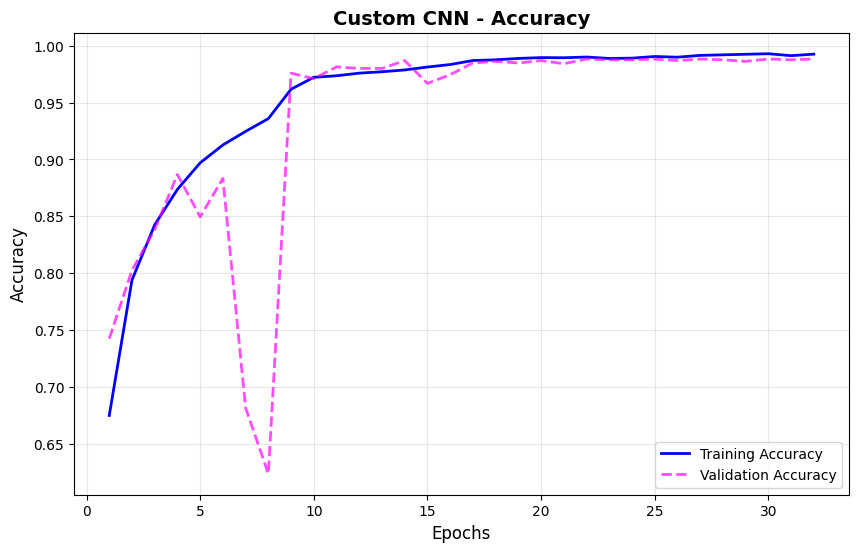

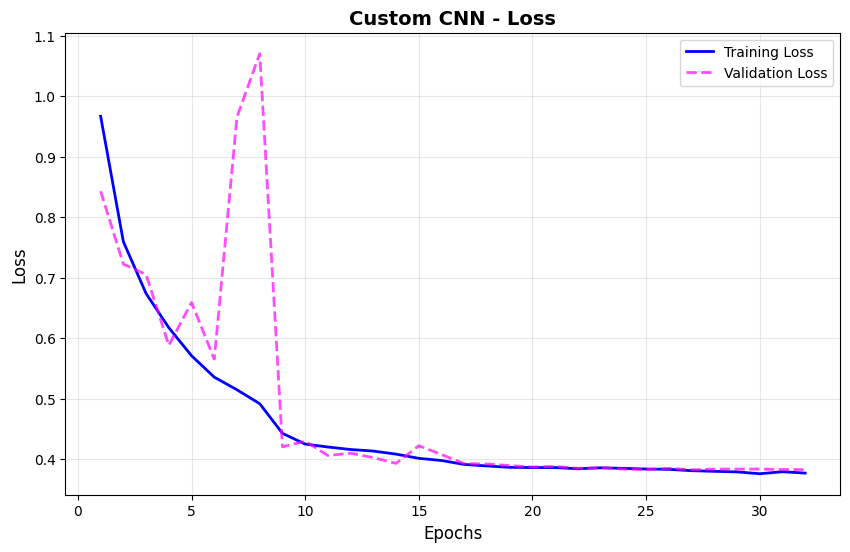

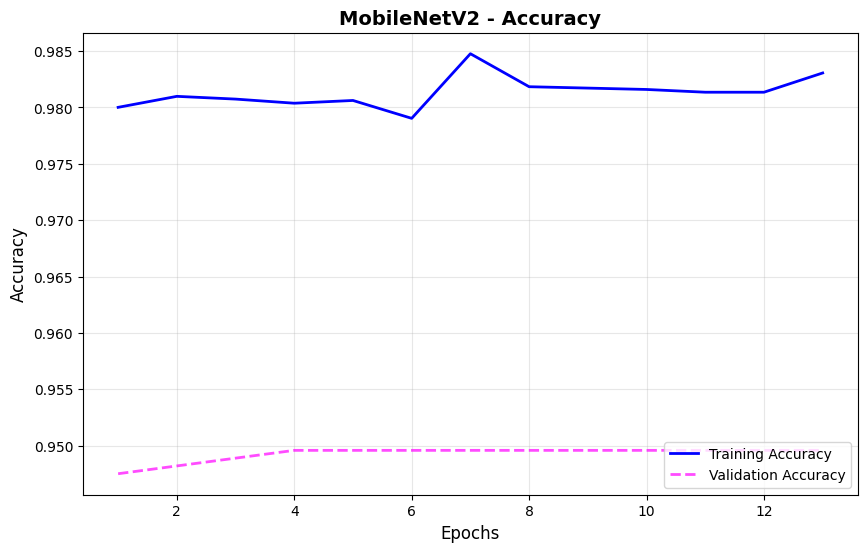

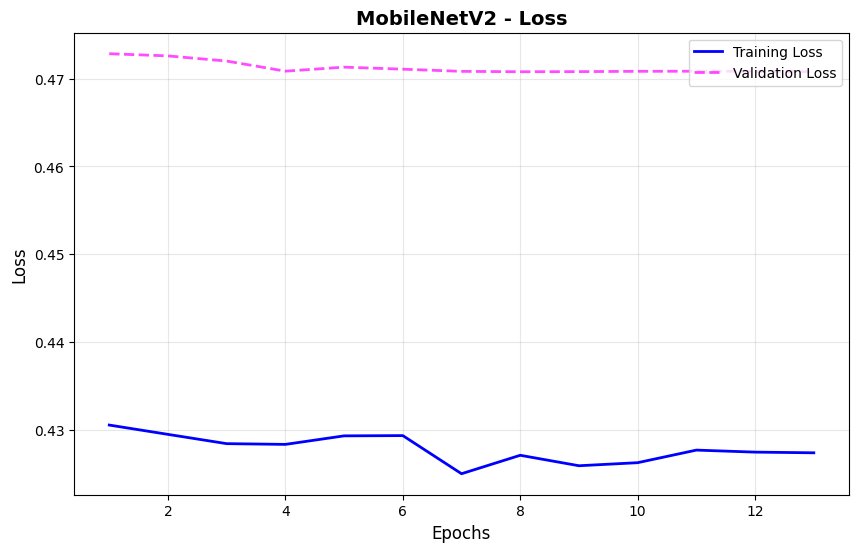

   GENERATING PREDICTIONS
Predicting with Custom CNN...
Predicting with MobileNetV2...
Creating Hybrid Ensemble...
REPORT: Custom CNN
Final Accuracy: 96.56%
              precision    recall  f1-score   support

      glioma       0.98      0.92      0.95       755
  meningioma       0.92      0.96      0.94       546
   pituitary       0.99      1.00      1.00       626
     notumor       0.95      1.00      0.98       487

    accuracy                           0.97      2414
   macro avg       0.96      0.97      0.97      2414
weighted avg       0.97      0.97      0.97      2414



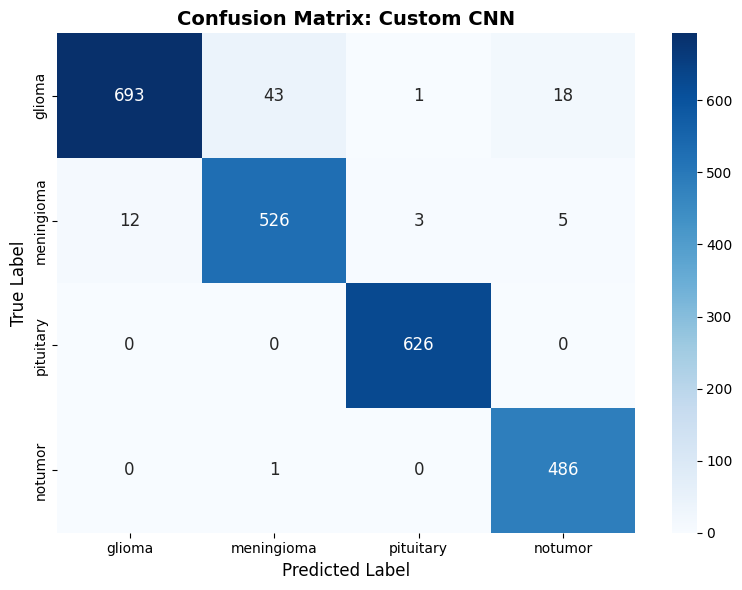

REPORT: MobileNetV2
Final Accuracy: 88.69%
              precision    recall  f1-score   support

      glioma       0.90      0.82      0.86       755
  meningioma       0.78      0.79      0.79       546
   pituitary       0.91      0.97      0.94       626
     notumor       0.95      0.99      0.97       487

    accuracy                           0.89      2414
   macro avg       0.89      0.89      0.89      2414
weighted avg       0.89      0.89      0.89      2414



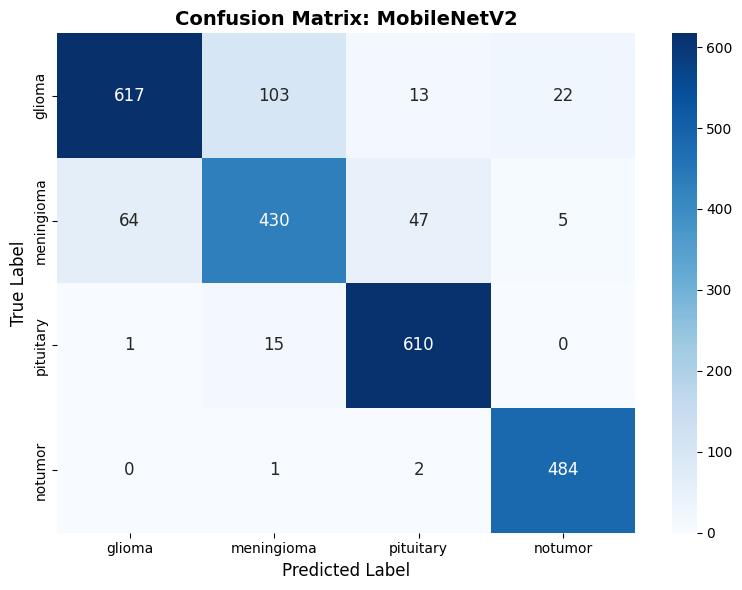

REPORT: Hybrid Ensemble
Final Accuracy: 96.23%
              precision    recall  f1-score   support

      glioma       0.99      0.91      0.95       755
  meningioma       0.92      0.96      0.94       546
   pituitary       0.98      1.00      0.99       626
     notumor       0.95      1.00      0.97       487

    accuracy                           0.96      2414
   macro avg       0.96      0.97      0.96      2414
weighted avg       0.96      0.96      0.96      2414



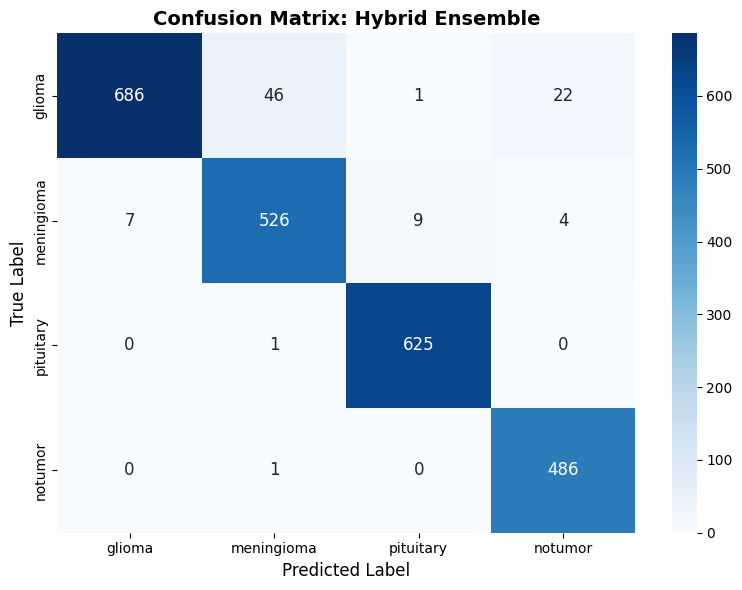

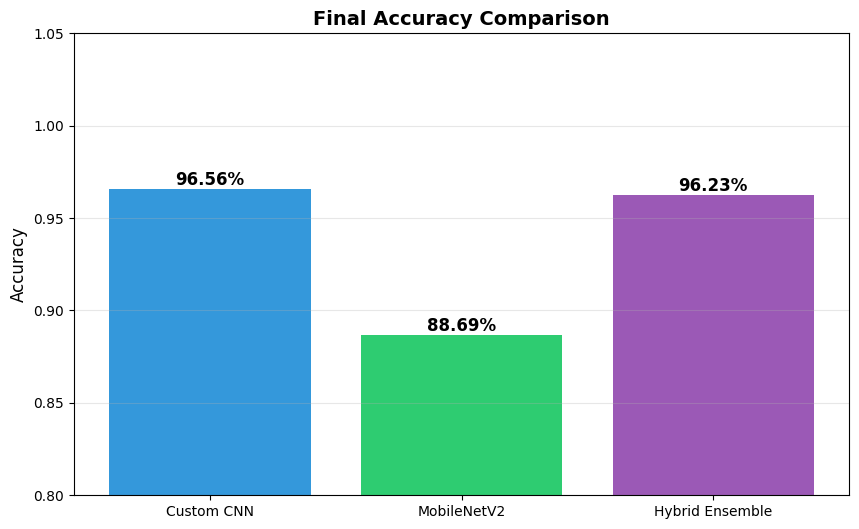

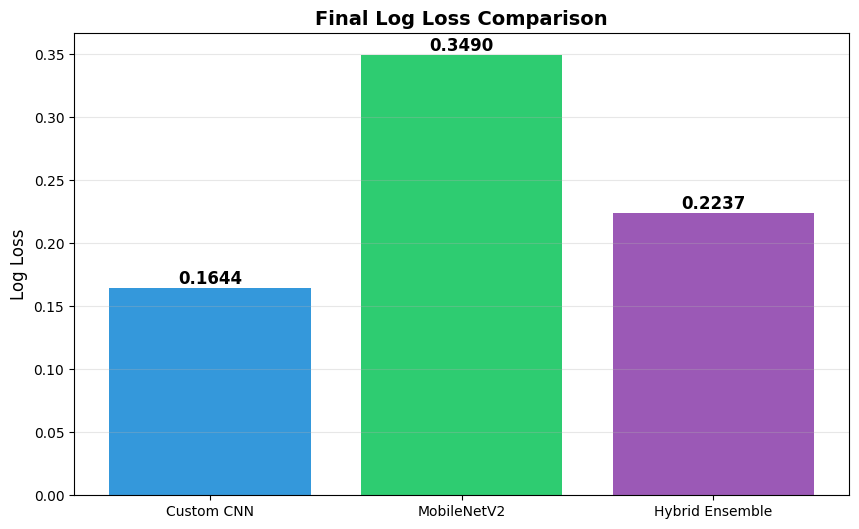

In [ ]:
# Cell 6: Comprehensive Evaluation (Individual Graphs & Reports)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss

# 1. INDIVIDUAL TRAINING GRAPHS

def plot_metric(history, metric, model_name):
    """Plots a single metric (Accuracy or Loss) on a separate figure"""

    # Determine metric keys
    if metric == 'Accuracy':
        train_key = 'accuracy' if 'accuracy' in history.history else 'acc'
        val_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
        ylabel = 'Accuracy'
        loc = 'lower right'
    else:
        train_key = 'loss'
        val_key = 'val_loss'
        ylabel = 'Loss'
        loc = 'upper right'

    train_data = history.history[train_key]
    val_data = history.history[val_key]
    epochs_range = range(1, len(train_data) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_data, label=f'Training {metric}', color='blue', linewidth=2)
    plt.plot(epochs_range, val_data, label=f'Validation {metric}', color='magenta', linestyle='--', linewidth=2, alpha=0.7)
    plt.title(f'{model_name} - {metric}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(loc=loc)
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot the 4 Training Graphs Individually
# CNN
plot_metric(hist_cnn, 'Accuracy', 'Custom CNN')
plot_metric(hist_cnn, 'Loss', 'Custom CNN')

# MobileNet
plot_metric(hist_mob, 'Accuracy', 'MobileNetV2')
plot_metric(hist_mob, 'Loss', 'MobileNetV2')

# 2. GENERATE PREDICTIONS & ENSEMBLE

print("   GENERATING PREDICTIONS")

# 1. Custom CNN
print("Predicting with Custom CNN...")
probs_cnn = model_cnn.predict(test_ds_cnn, verbose=0)
preds_cnn = np.argmax(probs_cnn, axis=1)

# 2. MobileNetV2
print("Predicting with MobileNetV2...")
probs_mob = model_mob.predict(test_ds_mob, verbose=0)
preds_mob = np.argmax(probs_mob, axis=1)

# 3. Hybrid Ensemble (Average Fusion)
print("Creating Hybrid Ensemble...")
probs_ens = (probs_cnn + probs_mob) / 2.0
preds_ens = np.argmax(probs_ens, axis=1)

# True Labels
y_true = np.array(test_labels_raw)


# 3. REPORTS & CONFUSION MATRICES

models_data = [
    ("Custom CNN", preds_cnn),
    ("MobileNetV2", preds_mob),
    ("Hybrid Ensemble", preds_ens)
]

for name, preds in models_data:
    acc = accuracy_score(y_true, preds)

    # A. Classification Report
    print(f"REPORT: {name}")
    print(f"Final Accuracy: {acc:.2%}") # Accuracy on top
    print(classification_report(y_true, preds, target_names=CLASSES))

    # B. Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show() # Separate figure for each matrix


# 4. ENSEMBLE COMPARISON GRAPHS

# Calculate Losses
loss_cnn_final = log_loss(tf.keras.utils.to_categorical(y_true), probs_cnn)
loss_mob_final = log_loss(tf.keras.utils.to_categorical(y_true), probs_mob)
loss_ens_final = log_loss(tf.keras.utils.to_categorical(y_true), probs_ens)

model_names = ['Custom CNN', 'MobileNetV2', 'Hybrid Ensemble']
accuracies = [accuracy_score(y_true, preds_cnn), accuracy_score(y_true, preds_mob), accuracy_score(y_true, preds_ens)]
losses = [loss_cnn_final, loss_mob_final, loss_ens_final]

# Graph A: Accuracy Comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['#3498db', '#2ecc71', '#9b59b6'])
plt.title('Final Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.8, 1.05) # Adjust limits to show differences
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.2%}", ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Graph B: Loss Comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, losses, color=['#3498db', '#2ecc71', '#9b59b6'])
plt.title('Final Log Loss Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Log Loss', fontsize=12)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()